# Z-Buffer y depth testing

## 1. Importar librerías

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Definición de la escena 3D

Se define un conjunto de triángulos 3D con vértices y colores que se solapan en el espacio de pantalla pero difieren en profundidad. Esta escena se usará para probar escenarios de oclusión.

In [142]:
# Each triangle: 3 vertices (x, y, z) and a color
# Vertices are in world space; camera looks down -Z axis

triangles = [
    {
        "vertices": np.array([
            [-1.0,  -0.5,  -3.0],
            [ 1.0,  -0.5,  -3.0],
            [ 0.0,   1.0,  -3.0],
        ]),
        "color": np.array([1.0, 0.2, 0.2]),  # Red
        "name": "Red triangle (z=-3)"
    },
    {
        "vertices": np.array([
            [-0.5,  -1.0,  -2.5],
            [ 1.5,  -1.0,  -2.5],
            [ 0.5,   0.5,  -2.5],
        ]),
        "color": np.array([0.2, 0.8, 0.2]),  # Green
        "name": "Green triangle (z=-2.5)"
    },
    {
        "vertices": np.array([
            [-1.5,   0.0,  -4.0],
            [ 0.5,   0.0,  -4.0],
            [-0.5,   1.5,  -4.0],
        ]),
        "color": np.array([0.2, 0.4, 1.0]),  # Blue
        "name": "Blue triangle (z=-4)"
    },
]

## 3. Función de proyección 3D a 2D

Proyecta puntos 3D a coordenadas de pantalla 2D usando proyección en perspectiva. Incluye parámetros para near plane, far plane, campo de visión y dimensiones de imagen.

In [143]:
def project_vertices(vertices, width=512, height=512, fov=60.0, near=0.1, far=100.0):
    """
    Project 3D vertices to 2D screen coordinates using perspective projection.

    Parameters:
    vertices : np.ndarray (N, 3)
        3D vertex positions (camera space, looking down -Z)
    width, height : int
        Image dimensions in pixels
    fov : float
        Vertical field of view in degrees
    near, far : float
        Near and far clipping planes

    Returns:
    screen_coords : np.ndarray (N, 2)
        2D pixel coordinates (x, y)
    depths : np.ndarray (N,)
        Depth values (positive, smaller = closer)
    """
    aspect = width / height
    fov_rad = np.radians(fov)
    f = 1.0 / np.tan(fov_rad / 2.0)

    projected = np.zeros((len(vertices), 2))
    depths = np.zeros(len(vertices))

    for i, v in enumerate(vertices):
        x, y, z = v
        # Camera looks down -Z, so depth is -z (positive value)
        depth = -z
        depths[i] = depth

        # Perspective divide
        xp = (f / aspect) * x / depth
        yp = f * y / depth

        # NDC [-1, 1] to screen [0, width/height]
        sx = (xp + 1.0) * 0.5 * width
        sy = (1.0 - yp) * 0.5 * height  # Flip Y for screen space

        projected[i] = [sx, sy]

    return projected, depths

## 4. Función de rasterización de triángulos

Itera sobre los píxeles dentro del bounding box del triángulo, calcula coordenadas baricéntricas para determinar si un píxel está dentro del triángulo, e interpola los valores de profundidad y color.

In [144]:
def barycentric(px, py, v0, v1, v2):
    """
    Compute barycentric coordinates (u, v, w) of point (px, py)
    with respect to triangle (v0, v1, v2) in 2D.
    """
    d00 = v1[0] - v0[0]
    d01 = v2[0] - v0[0]
    d10 = v1[1] - v0[1]
    d11 = v2[1] - v0[1]

    denom = d00 * d11 - d01 * d10
    if abs(denom) < 1e-10:
        return -1, -1, -1  # Degenerate triangle

    dx = px - v0[0]
    dy = py - v0[1]

    v = (dx * d11 - d01 * dy) / denom
    w = (d00 * dy - dx * d10) / denom
    u = 1.0 - v - w

    return u, v, w


def rasterize_triangle(screen_coords, depths, color, color_buffer, z_buffer=None, use_zbuffer=True):
    """
    Rasterize a single triangle into the color buffer (and optionally the Z-buffer).

    Parameters:
    screen_coords : np.ndarray (3, 2)
        2D screen coordinates of the triangle vertices
    depths : np.ndarray (3,)
        Depth values at each vertex
    color : np.ndarray (3,)
        RGB color of the triangle (0-1)
    color_buffer : np.ndarray (H, W, 3)
        Output color image
    z_buffer : np.ndarray (H, W) or None
        Depth buffer (required if use_zbuffer=True)
    use_zbuffer : bool
        Whether to perform depth testing
    """
    h, w = color_buffer.shape[:2]

    v0, v1, v2 = screen_coords
    d0, d1, d2 = depths

    # Bounding box (clamped to image)
    min_x = max(0, int(np.floor(min(v0[0], v1[0], v2[0]))))
    max_x = min(w - 1, int(np.ceil(max(v0[0], v1[0], v2[0]))))
    min_y = max(0, int(np.floor(min(v0[1], v1[1], v2[1]))))
    max_y = min(h - 1, int(np.ceil(max(v0[1], v1[1], v2[1]))))

    for y in range(min_y, max_y + 1):
        for x in range(min_x, max_x + 1):
            u, v, w_bary = barycentric(x + 0.5, y + 0.5, v0, v1, v2)

            # Check if pixel is inside the triangle
            if u >= 0 and v >= 0 and w_bary >= 0:
                # Interpolate depth
                z = u * d0 + v * d1 + w_bary * d2

                if use_zbuffer:
                    # Z-buffer test: update only if closer
                    if z < z_buffer[y, x]:
                        z_buffer[y, x] = z
                        color_buffer[y, x] = color
                else:
                    # No Z-buffer: simply overwrite
                    color_buffer[y, x] = color

## 5. Renderizado sin Z-Buffer (Painter's Algorithm)

Se ordenan los triángulos por profundidad promedio (de atrás hacia adelante) y se renderizan en orden

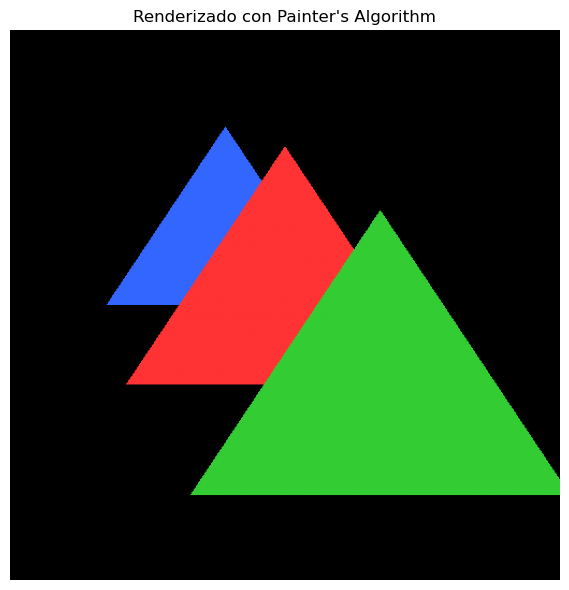

In [145]:
def render_painters(triangles_list, width=512, height=512, fov=60.0):
    """
    Render a scene using the Painter's Algorithm (no Z-buffer).
    Triangles are sorted by average depth (back to front) and drawn in order.

    Parameters:
    triangles_list : list of dict
        Each dict has 'vertices' (3x3), 'color' (3,), 'name' (str)

    Returns:
    color_buffer : np.ndarray (H, W, 3)
    """
    color_buffer = np.zeros((height, width, 3))

    # Compute average depth for each triangle and sort back-to-front
    tri_with_depth = []
    for tri in triangles_list:
        avg_z = -np.mean(tri["vertices"][:, 2])  # -z = positive depth
        tri_with_depth.append((avg_z, tri))

    # Sort by depth: farthest first (largest depth first)
    tri_with_depth.sort(key=lambda x: x[0], reverse=True)

    for depth, tri in tri_with_depth:
        sc, dp = project_vertices(tri["vertices"], width, height, fov)
        rasterize_triangle(sc, dp, tri["color"], color_buffer, use_zbuffer=False)

    return color_buffer


# Render without Z-buffer
img_painters = render_painters(triangles)

plt.figure(figsize=(6, 6))
plt.imshow(img_painters)
plt.title("Renderizado con Painter's Algorithm")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "painters_algorithm.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Demostrar Artefactos del Painter's Algorithm

Se construye una escena donde el Painter's Algorithm falla: triángulos que se intersectan y no tienen un orden válido de atrás hacia adelante, generando artefactos de oclusión.

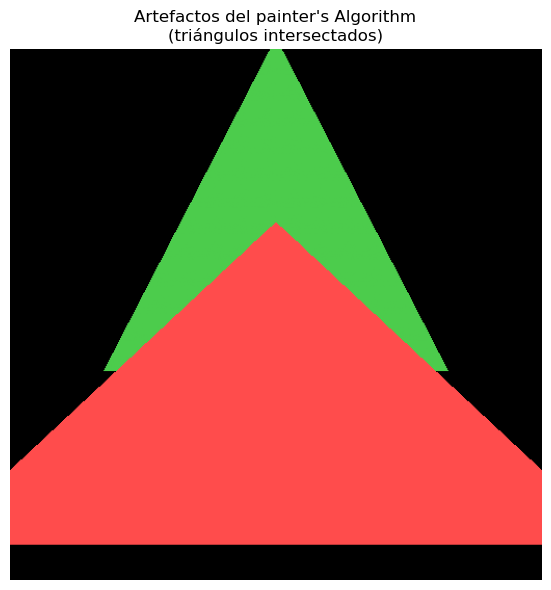

In [146]:
# Intersecting triangles: one triangle passes through another
# No valid back-to-front ordering exists for this case
intersecting_triangles = [
    {
        "vertices": np.array([
            [-1.5,  -1.0,  -2.0],
            [ 1.5,  -1.0,  -2.0],
            [ 0.0,   1.0,  -5.0],  # Tip goes deep into the scene
        ]),
        "color": np.array([1.0, 0.3, 0.3]),  # Red
        "name": "Red (intersecting, z=-2 to z=-5)"
    },
    {
        "vertices": np.array([
            [-1.5,  -0.5,  -4.0],
            [ 1.5,  -0.5,  -4.0],
            [ 0.0,   1.5,  -2.5],  # Tip comes forward
        ]),
        "color": np.array([0.3, 0.8, 0.3]),  # Green
        "name": "Green (intersecting, z=-4 to z=-2.5)"
    },
]

# Render with Painter's Algorithm
img_artifacts = render_painters(intersecting_triangles)

plt.figure(figsize=(6, 6))
plt.imshow(img_artifacts)
plt.title("Artefactos del painter's Algorithm\n(triángulos intersectados)")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "painters_artifacts_intersection.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Implementar estructura del Z-Buffer

Se crea el depth buffer con las mismas dimensiones que el color buffer. Se inicializa con valores infinitos, representando la mayor profundidad posible. El Z-buffer permite la comparación de profundidad por píxel.

In [147]:
def create_buffers(width=512, height=512):
    """
    Create and initialize color buffer and Z-buffer.

    Parameters:
    width, height : int
        Image dimensions

    Returns:
    color_buffer : np.ndarray (H, W, 3) - initialized to black
    z_buffer : np.ndarray (H, W) - initialized to infinity
    """
    color_buffer = np.zeros((height, width, 3))
    z_buffer = np.full((height, width), np.inf)

    return color_buffer, z_buffer

color_buf, z_buf = create_buffers()

## 8. Renderizado con Z-Buffer

Pipeline completo de renderizado con Z-buffer: para cada píxel rasterizado, se calcula el valor Z interpolado, se compara con el valor actual del Z-buffer, y se actualizan ambos buffers solo si el nuevo Z es menor.

In [148]:
def render_zbuffer(triangles_list, width=512, height=512, fov=60.0):
    """
    Render a scene using the Z-buffer algorithm.

    Parameters:
    triangles_list : list of dict
        Each dict has 'vertices' (3x3), 'color' (3,), 'name' (str)

    Returns:
    color_buffer : np.ndarray (H, W, 3)
    z_buffer : np.ndarray (H, W)
    """
    color_buffer, z_buffer = create_buffers(width, height)

    for tri in triangles_list:
        sc, dp = project_vertices(tri["vertices"], width, height, fov)
        rasterize_triangle(sc, dp, tri["color"], color_buffer, z_buffer, use_zbuffer=True)
        
    return color_buffer, z_buffer

## 9. Renderizar escena con oclusiones correctas

Se renderiza la escena con los triángulos intersectados usando el Z-buffer. El resultado muestra que la oclusión se maneja correctamente sin importar el orden de renderizado.

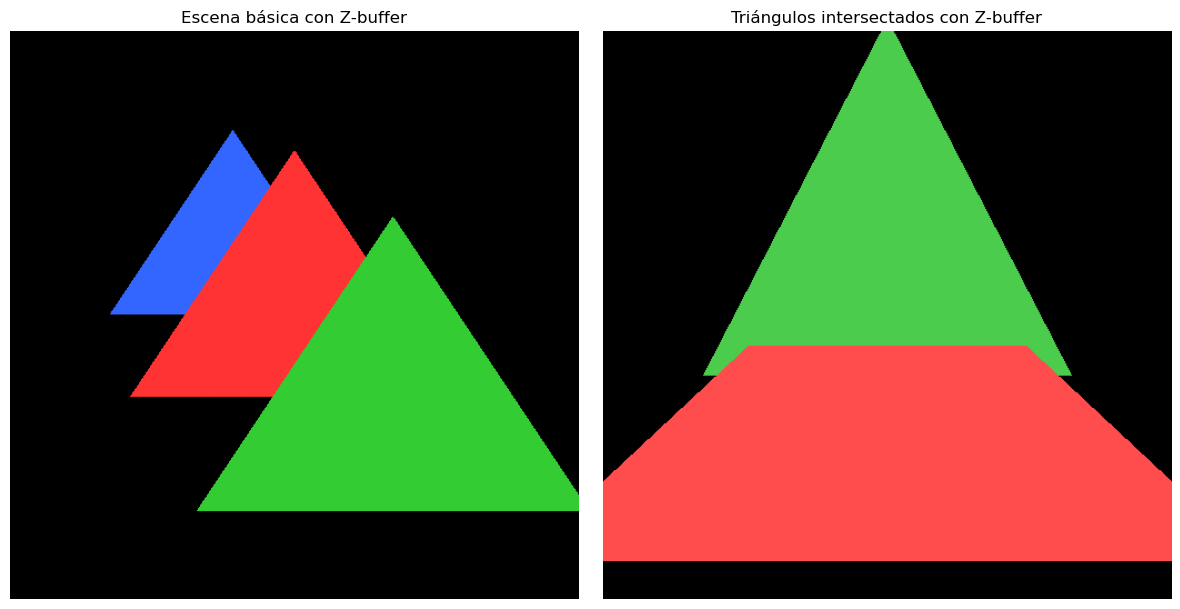

In [149]:
# Render both scenes with Z-buffer
img_zbuf_basic, zbuf_basic = render_zbuffer(triangles)
print()
img_zbuf_intersecting, zbuf_intersecting = render_zbuffer(intersecting_triangles)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_zbuf_basic)
axes[0].set_title("Escena básica con Z-buffer")
axes[0].axis("off")

axes[1].imshow(img_zbuf_intersecting)
axes[1].set_title("Triángulos intersectados con Z-buffer")
axes[1].axis("off")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "zbuffer_correct_occlusion.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Visualizar el depth buffer como imagen en escala de grises

Se normalizan los valores del Z-buffer al rango [0, 1] y se muestran como imagen en escala de grises. Objetos más cercanos aparecen más oscuros, objetos más lejanos aparecen más claros.

Depth range: [2.5000, 4.0000]


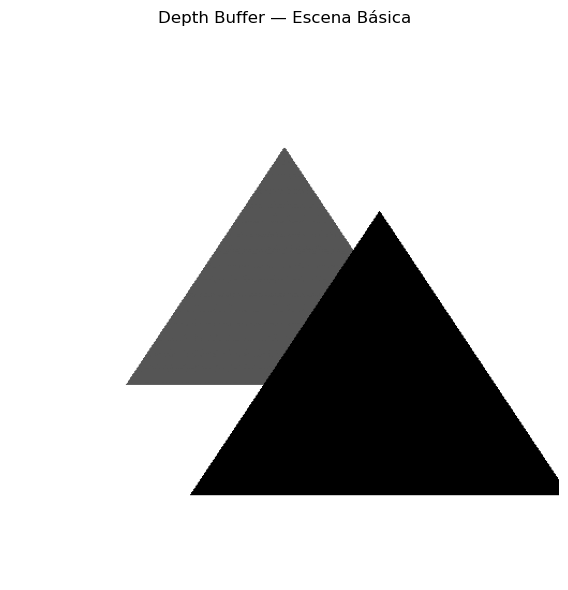


Depth range: [2.0020, 3.9957]


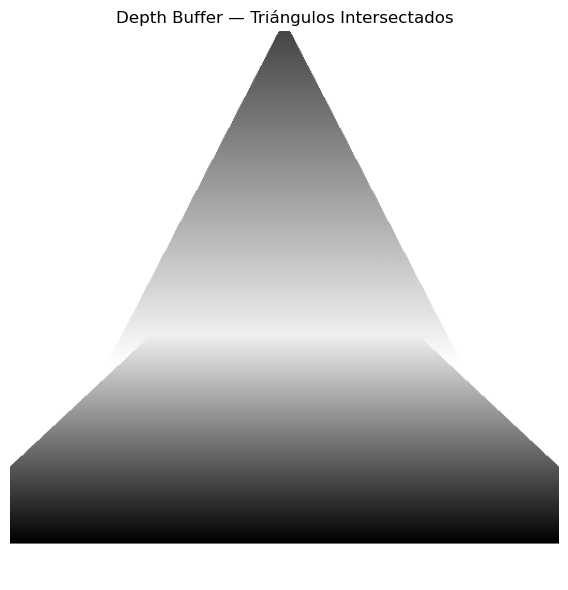

In [150]:
def visualize_depth_buffer(z_buffer, title="Depth Buffer", save_path=None):
    """
    Normalize and display the Z-buffer as a grayscale image.

    Parameters:
    z_buffer : np.ndarray (H, W)
        The depth buffer
    title : str
        Title for the plot
    save_path : str or None
        If provided, save the image to this path
    """
    # Create a copy and replace infinity with NaN for visualization
    zbuf_vis = z_buffer.copy()
    mask = np.isinf(zbuf_vis)

    if np.all(mask):
        print("Z-buffer is empty (all infinity)")
        return

    # Get min/max of valid (non-infinity) values
    valid_values = zbuf_vis[~mask]
    z_min, z_max = valid_values.min(), valid_values.max()

    print(f"Depth range: [{z_min:.4f}, {z_max:.4f}]")

    # Normalize to [0, 1]
    if z_max > z_min:
        zbuf_normalized = (zbuf_vis - z_min) / (z_max - z_min)
    else:
        zbuf_normalized = np.zeros_like(zbuf_vis)

    # Set background (infinity) to white
    zbuf_normalized[mask] = 1.0

    plt.figure(figsize=(6, 6))
    plt.imshow(zbuf_normalized, cmap="gray", vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()

    # Save the matplotlib figure
    if save_path:
        plt.savefig(os.path.join(OUTPUT_DIR, save_path), dpi=150, bbox_inches="tight")

    plt.show()

    return zbuf_normalized


# Visualize depth buffers
zbuf_norm_basic = visualize_depth_buffer(zbuf_basic, "Depth Buffer — Escena Básica", "depth_buffer_basic_scene.png")
print()
zbuf_norm_inter = visualize_depth_buffer(zbuf_intersecting, "Depth Buffer — Triángulos Intersectados", "depth_buffer_intersecting.png")

## 11. Analizar distribución de valores de profundidad

Se grafica un histograma de los valores de profundidad almacenados en el Z-buffer.

Total pixels with depth data: 78,770
  Min depth: 2.5000
  Max depth: 4.0000
  Mean depth: 2.8232
  Std deviation: 0.4885


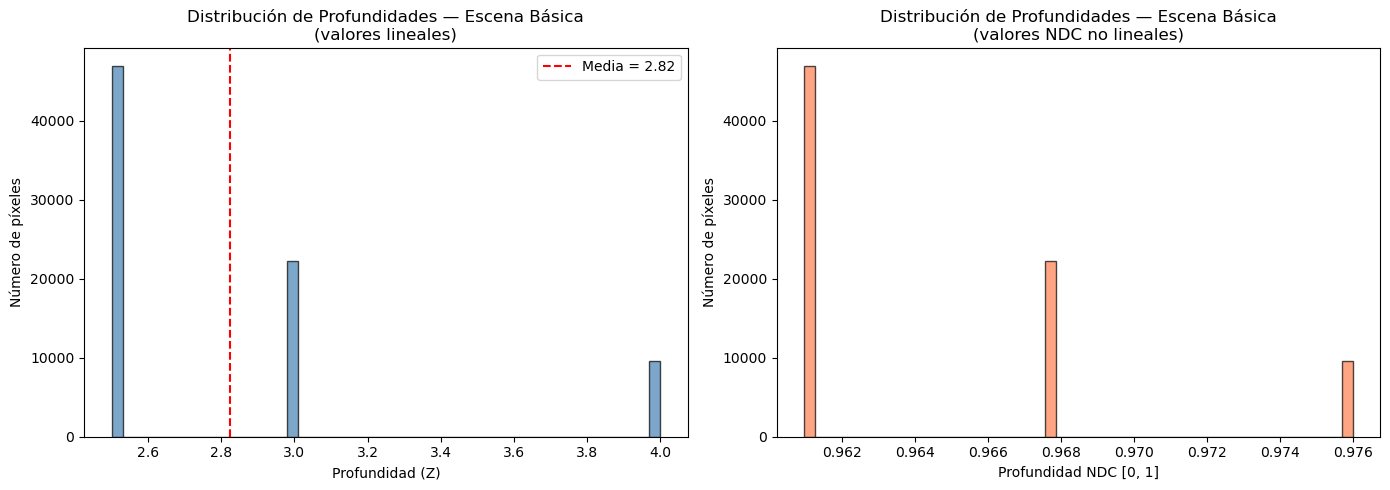

In [151]:
def analyze_depth_distribution(z_buffer, title="Distribución de Profundidades", save_path=None):
    """
    Plot histogram of depth values stored in the Z-buffer.

    Parameters:
    z_buffer : np.ndarray (H, W)
        The depth buffer
    title : str
        Title for the plot
    save_path : str or None
        If provided, save the figure to this path inside OUTPUT_DIR
    """
    # Extract valid (non-infinity) depth values
    valid_depths = z_buffer[~np.isinf(z_buffer)].flatten()

    if len(valid_depths) == 0:
        print("No valid depth values found.")
        return

    print(f"Total pixels with depth data: {len(valid_depths):,}")
    print(f"  Min depth: {valid_depths.min():.4f}")
    print(f"  Max depth: {valid_depths.max():.4f}")
    print(f"  Mean depth: {valid_depths.mean():.4f}")
    print(f"  Std deviation: {valid_depths.std():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of raw depth values
    axes[0].hist(valid_depths, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
    axes[0].set_xlabel("Profundidad (Z)")
    axes[0].set_ylabel("Número de píxeles")
    axes[0].set_title(f"{title}\n(valores lineales)")
    axes[0].axvline(valid_depths.mean(), color="red", linestyle="--", label=f"Media = {valid_depths.mean():.2f}")
    axes[0].legend()

    # Simulate non-linear depth buffer (as in hardware)
    near, far = 0.1, 100.0
    # z_ndc = (far + near) / (far - near) + (2*far*near) / ((far - near) * depth)
    # This mimics the non-linear distribution of a perspective depth buffer
    z_ndc = (far * (valid_depths - near)) / (valid_depths * (far - near))

    axes[1].hist(z_ndc, bins=50, color="coral", edgecolor="black", alpha=0.7)
    axes[1].set_xlabel("Profundidad NDC [0, 1]")
    axes[1].set_ylabel("Número de píxeles")
    axes[1].set_title(f"{title}\n(valores NDC no lineales)")

    plt.tight_layout()

    if save_path:
        fig.savefig(os.path.join(OUTPUT_DIR, save_path), dpi=150, bbox_inches="tight")

    plt.show()


analyze_depth_distribution(zbuf_basic, "Distribución de Profundidades — Escena Básica", "depth_distribution.png")

## 12. Comparación lado a lado: Con vs sin Z-Buffer

Se renderiza la misma escena con ambos métodos y se crea una figura con subplots lado a lado. Se calcula una imagen de diferencia píxel a píxel para identificar claramente dónde ocurren errores de oclusión.


Diferencias:
Píxeles con color: 129,040
Píxeles incorrectos sin Z-buffer: 14,580
Porcentaje de error: 11.30%


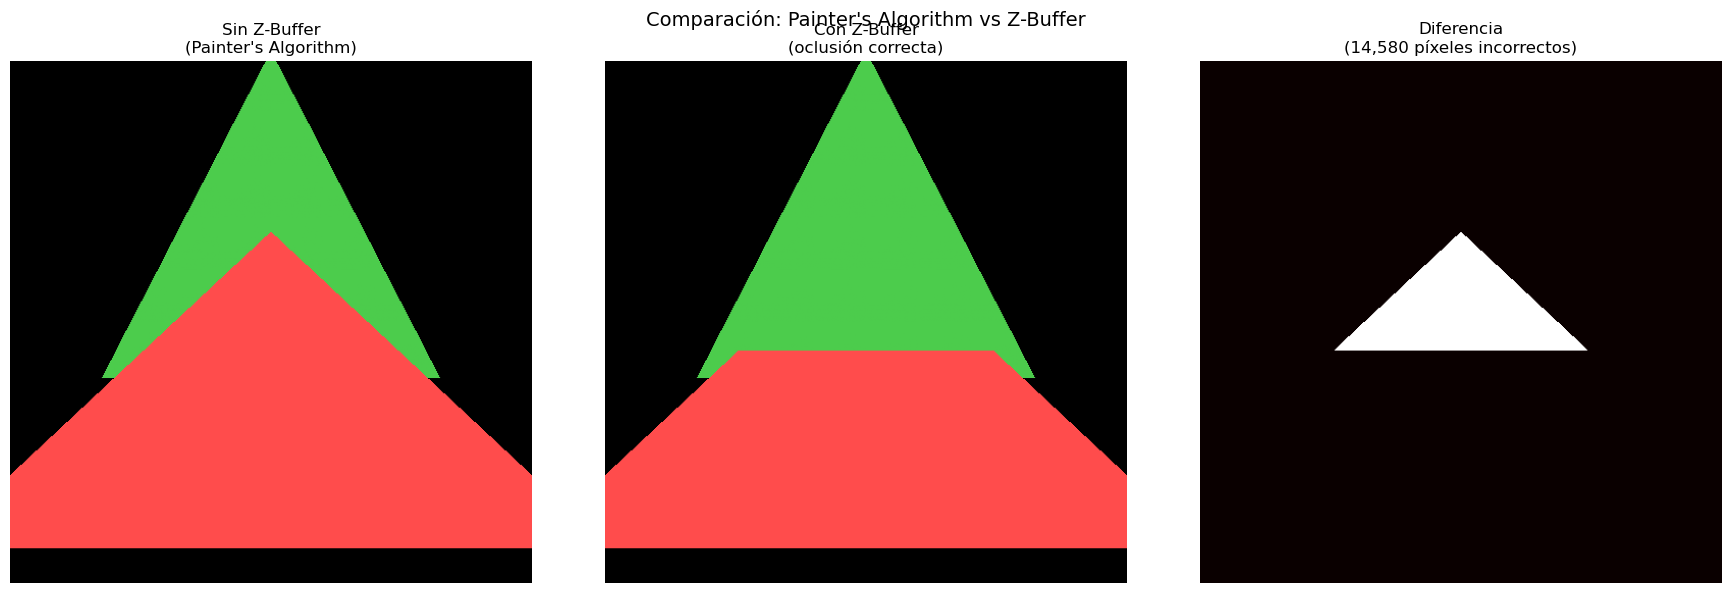

In [152]:
# Render the intersecting scene with both methods
img_no_zbuf = render_painters(intersecting_triangles)
print()
img_with_zbuf, _ = render_zbuffer(intersecting_triangles)

# Compute pixel-wise difference
difference = np.abs(img_with_zbuf - img_no_zbuf)
diff_magnitude = np.sum(difference, axis=2)  # Sum across RGB channels

# Count incorrect pixels
incorrect_pixels = np.sum(diff_magnitude > 0.01)
total_colored = np.sum(np.any(img_with_zbuf > 0, axis=2))

print(f"Diferencias:")
print(f"Píxeles con color: {total_colored:,}")
print(f"Píxeles incorrectos sin Z-buffer: {incorrect_pixels:,}")
if total_colored > 0: print(f"Porcentaje de error: {100.0 * incorrect_pixels / total_colored:.2f}%")

# Side-by-side visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_no_zbuf)
axes[0].set_title("Sin Z-Buffer\n(Painter's Algorithm)")
axes[0].axis("off")

axes[1].imshow(img_with_zbuf)
axes[1].set_title("Con Z-Buffer\n(oclusión correcta)")
axes[1].axis("off")

axes[2].imshow(diff_magnitude, cmap="hot")
axes[2].set_title(f"Diferencia\n({incorrect_pixels:,} píxeles incorrectos)")
axes[2].axis("off")

plt.suptitle("Comparación: Painter's Algorithm vs Z-Buffer", fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "comparison_with_without_zbuffer.png"), dpi=150, bbox_inches="tight")
plt.show()

## 13. Experimentación con precisión: Variando near/far planes

Se renderiza la escena con diferentes ratios near/far. Se visualiza el depth buffer para cada configuración y se observa cómo ratios extremos reducen la precisión de profundidad.

Rendering with near=0.1, far=100...
Unique depth values (6 decimals): 3
Depth range in NDC: [0.96096096, 0.97597598]
Effective precision: 0.01501502

Rendering with near=0.001, far=10,000...
Unique depth values (6 decimals): 3
Depth range in NDC: [0.99960010, 0.99975010]
Effective precision: 0.00015000

Rendering with near=0.0001, far=100,000...
Unique depth values (6 decimals): 3
Depth range in NDC: [0.99996000, 0.99997500]
Effective precision: 0.00001500



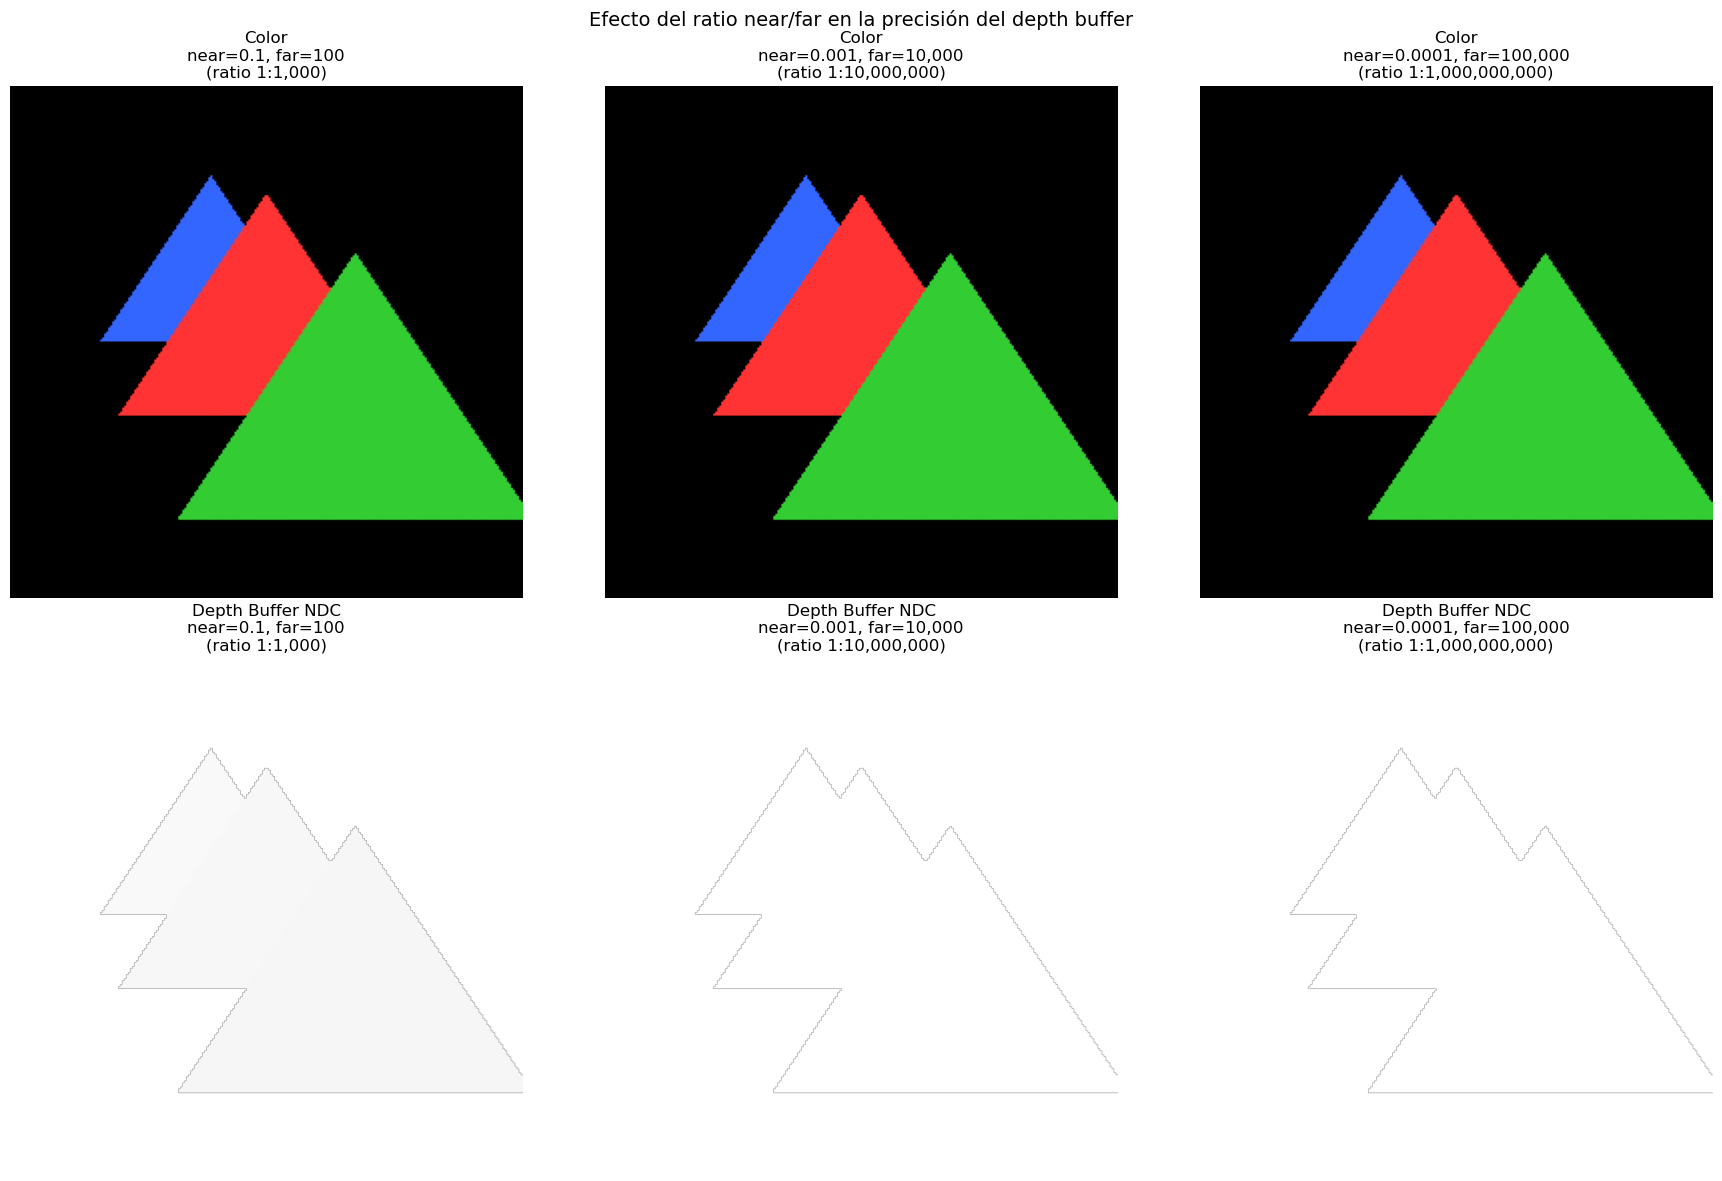

In [153]:
def render_with_ndc_depth(triangles_list, near, far, width=256, height=256, fov=60.0):
    """
    Render using NDC depth values (non-linear, as in GPU hardware).
    This simulates the precision behavior of a real depth buffer.
    
    Returns:
    color_buffer, z_buffer_ndc
    """
    color_buffer = np.zeros((height, width, 3))
    z_buffer_ndc = np.full((height, width), 1.0)  # NDC depth: 1.0 = far

    for tri in triangles_list:
        sc, dp = project_vertices(tri["vertices"], width, height, fov, near, far)

        v0, v1, v2 = sc
        d0, d1, d2 = dp

        # Bounding box
        min_x = max(0, int(np.floor(min(v0[0], v1[0], v2[0]))))
        max_x = min(width - 1, int(np.ceil(max(v0[0], v1[0], v2[0]))))
        min_y = max(0, int(np.floor(min(v0[1], v1[1], v2[1]))))
        max_y = min(height - 1, int(np.ceil(max(v0[1], v1[1], v2[1]))))

        for y in range(min_y, max_y + 1):
            for x in range(min_x, max_x + 1):
                u, v, w_b = barycentric(x + 0.5, y + 0.5, v0, v1, v2)
                if u >= 0 and v >= 0 and w_b >= 0:
                    z_linear = u * d0 + v * d1 + w_b * d2

                    # Convert to NDC depth (non-linear)
                    if z_linear > 0:
                        z_ndc = (far * (z_linear - near)) / (z_linear * (far - near))
                    else:
                        z_ndc = 0.0

                    z_ndc = np.clip(z_ndc, 0.0, 1.0)

                    if z_ndc < z_buffer_ndc[y, x]:
                        z_buffer_ndc[y, x] = z_ndc
                        color_buffer[y, x] = tri["color"]

    return color_buffer, z_buffer_ndc


# Test different near/far configurations
configs = [
    (0.1,    100,    "near=0.1, far=100\n(ratio 1:1,000)"),
    (0.001,  10000,  "near=0.001, far=10,000\n(ratio 1:10,000,000)"),
    (0.0001, 100000, "near=0.0001, far=100,000\n(ratio 1:1,000,000,000)"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, (near, far, label) in enumerate(configs):
    print(f"Rendering with {label.split(chr(10))[0]}...")
    img, zbuf_ndc = render_with_ndc_depth(triangles, near, far)

    # Color render
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Color\n{label}")
    axes[0, i].axis("off")

    # Depth buffer
    zbuf_vis = zbuf_ndc.copy()
    zbuf_vis[zbuf_vis >= 1.0] = np.nan
    axes[1, i].imshow(zbuf_vis, cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Depth Buffer NDC\n{label}")
    axes[1, i].axis("off")

    # Analyze precision
    valid = zbuf_ndc[zbuf_ndc < 1.0]
    if len(valid) > 0:
        unique_depths = len(np.unique(np.round(valid, decimals=6)))
        print(f"Unique depth values (6 decimals): {unique_depths}")
        print(f"Depth range in NDC: [{valid.min():.8f}, {valid.max():.8f}]")
        print(f"Effective precision: {valid.max() - valid.min():.8f}")
    print()

plt.suptitle("Efecto del ratio near/far en la precisión del depth buffer", fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "precision_near_far_planes.png"), dpi=150, bbox_inches="tight")
plt.show()

## 14. Z-Fighting con triángulos casi coplanares

Se crean dos triángulos que se cruzan con un ángulo muy pequeño entre sí (casi coplanares). Al estar tan cerca en profundidad a lo largo de su superficie, se producen artefactos de Z-fighting: píxeles alternantes donde el Z-buffer no puede resolver cuál triángulo está delante. Se varía el ángulo de inclinación (tilt) y se documenta el umbral en el cual aparece el Z-fighting.

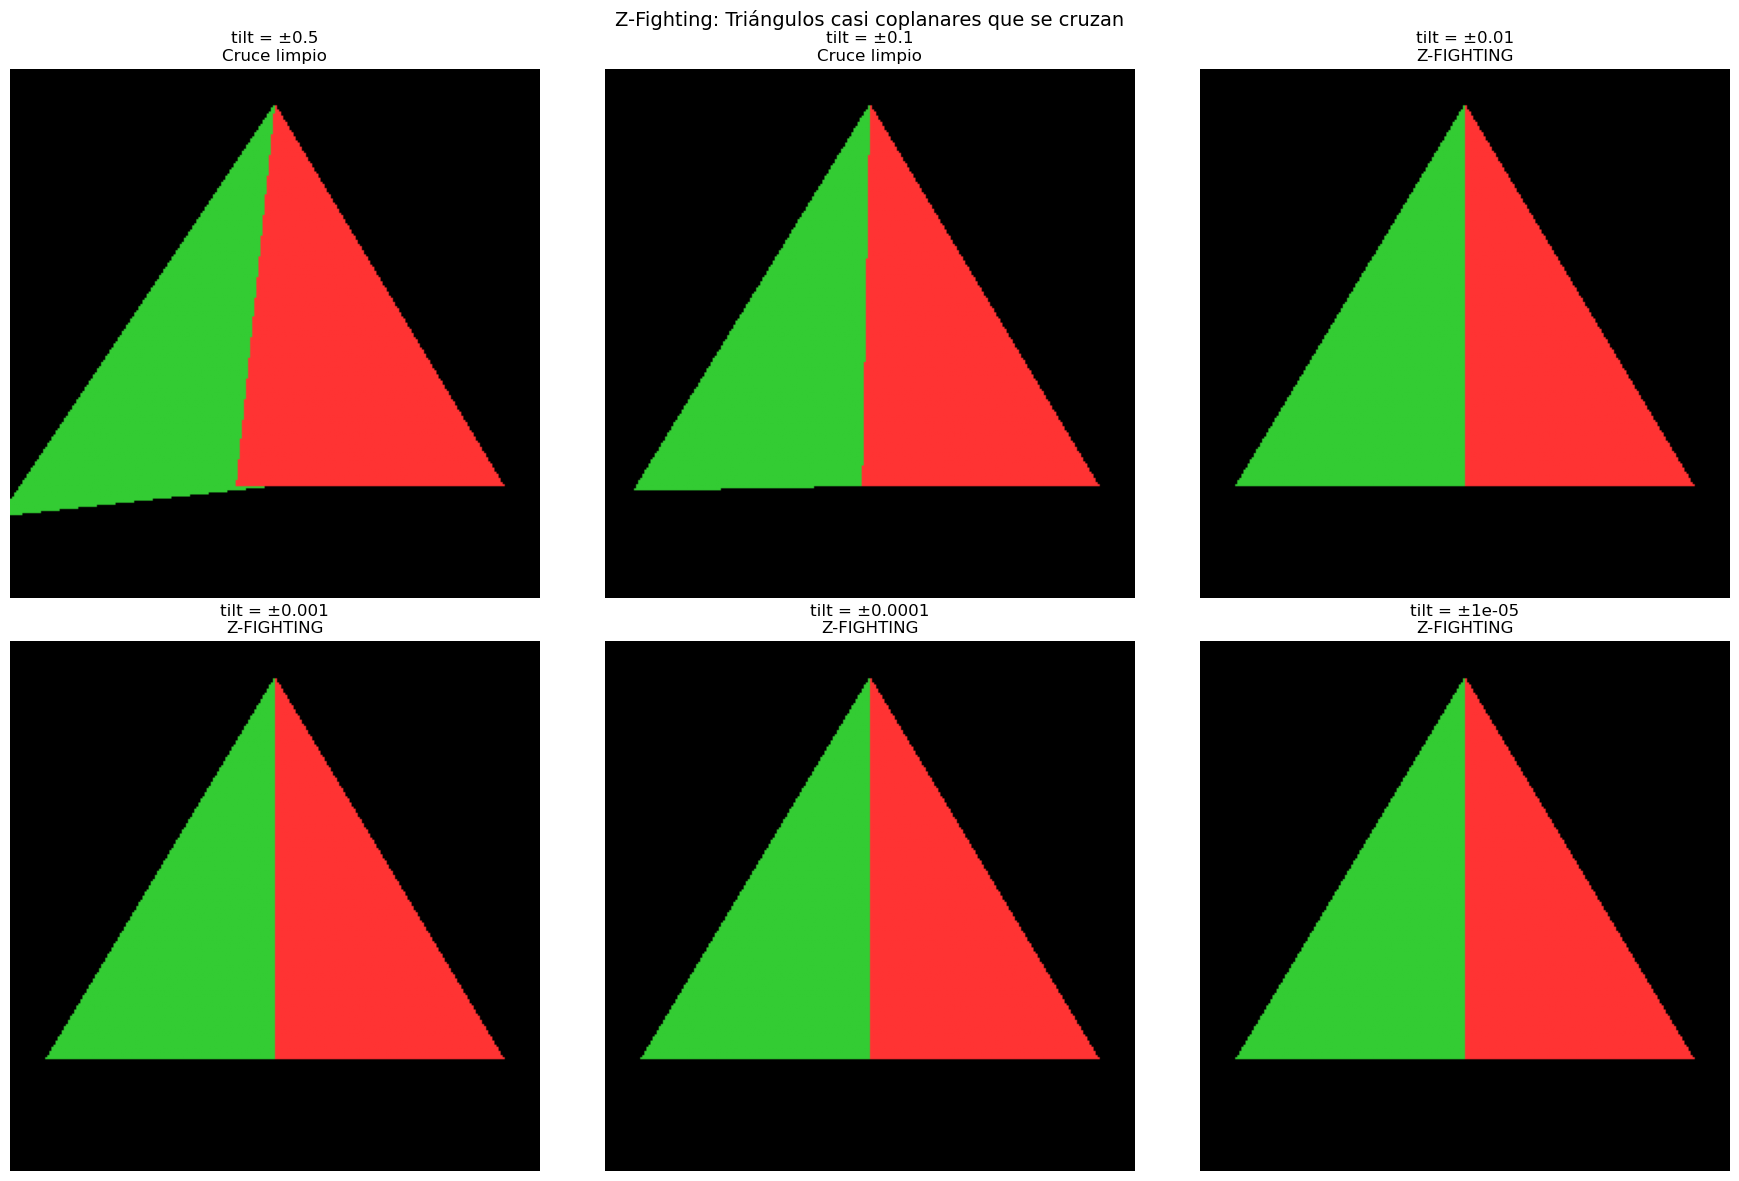

In [154]:
def create_zfighting_scene(base_depth, tilt):
    """
    Create two nearly-coplanar triangles that cross each other.
    
    One triangle is flat at base_depth. The other is tilted slightly
    so it crosses the first — in front on one side, behind on the other.
    When the tilt is very small, the depth difference at each pixel becomes
    so tiny that floating-point precision can't resolve it → Z-fighting.
    
    Parameters:
    base_depth : float
        Base depth (negative Z) for the flat triangle
    tilt : float
        Depth offset applied to one edge of the second triangle;
        the opposite edge gets -tilt, so the two planes intersect
    """
    return [
        {
            # Flat triangle at constant depth
            "vertices": np.array([
                [-1.5, -1.0, base_depth],
                [ 1.5, -1.0, base_depth],
                [ 0.0,  1.5, base_depth],
            ]),
            "color": np.array([1.0, 0.2, 0.2]),  # Red
            "name": f"Red (flat, z={base_depth})"
        },
        {
            # Tilted triangle: crosses through the red one
            # Left vertex is slightly behind, right vertex slightly in front
            "vertices": np.array([
                [-1.5, -1.0, base_depth + tilt],   # Behind red
                [ 1.5, -1.0, base_depth - tilt],   # In front of red
                [ 0.0,  1.5, base_depth],           # Same depth at top
            ]),
            "color": np.array([0.2, 0.8, 0.2]),  # Green
            "name": f"Green (tilted ±{tilt})"
        },
    ]


# Test Z-fighting with different tilt values
# Large tilt → clear crossing, no fighting. Tiny tilt → Z-fighting.
tilts = [0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001]
base_depth = -3.0

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes_flat = axes.flatten()

for i, tilt in enumerate(tilts):
    scene = create_zfighting_scene(base_depth, tilt)
    img, zbuf = render_zbuffer(scene, width=256, height=256)

    # Count pixels of each color to detect Z-fighting
    red_pixels = np.sum(np.all(np.abs(img - [1.0, 0.2, 0.2]) < 0.01, axis=2))
    green_pixels = np.sum(np.all(np.abs(img - [0.2, 0.8, 0.2]) < 0.01, axis=2))
    total_colored = red_pixels + green_pixels

    # Z-fighting: both colors should appear in the overlap zone
    # With a clear crossing, there IS a clean split (left=green behind, right=green in front)
    # With a tiny tilt, the split becomes noisy → Z-fighting
    if total_colored > 0:
        ratio = min(red_pixels, green_pixels) / total_colored
    else:
        ratio = 0.0

    # If ratio is between ~0.1 and 0.5 it means both colors are interspersed
    has_fighting = ratio > 0.01 and tilt < 0.05

    axes_flat[i].imshow(img)
    title_status = "Z-FIGHTING" if has_fighting else "Cruce limpio"
    axes_flat[i].set_title(f"tilt = ±{tilt}\n{title_status}")
    axes_flat[i].axis("off")

plt.suptitle("Z-Fighting: Triángulos casi coplanares que se cruzan", fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "zfighting_near_coplanar.png"), dpi=150, bbox_inches="tight")
plt.show()

## 15. Problemas de precisión y hallazgos

Resumen visual que muestra: (1) precisión del depth buffer como función de la distancia a la cámara, (2) relación entre ratio near/far y resolución efectiva de profundidad, y (3) tabla de umbrales de epsilon que causan Z-fighting en diferentes rangos de profundidad.

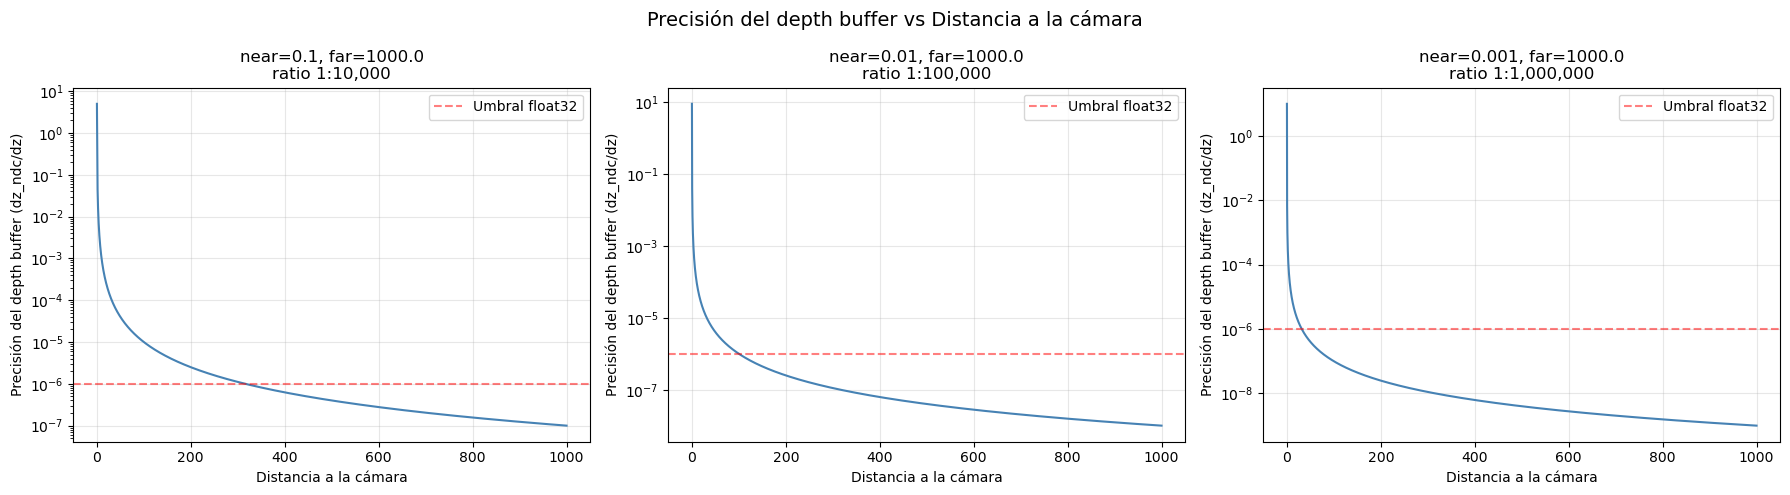

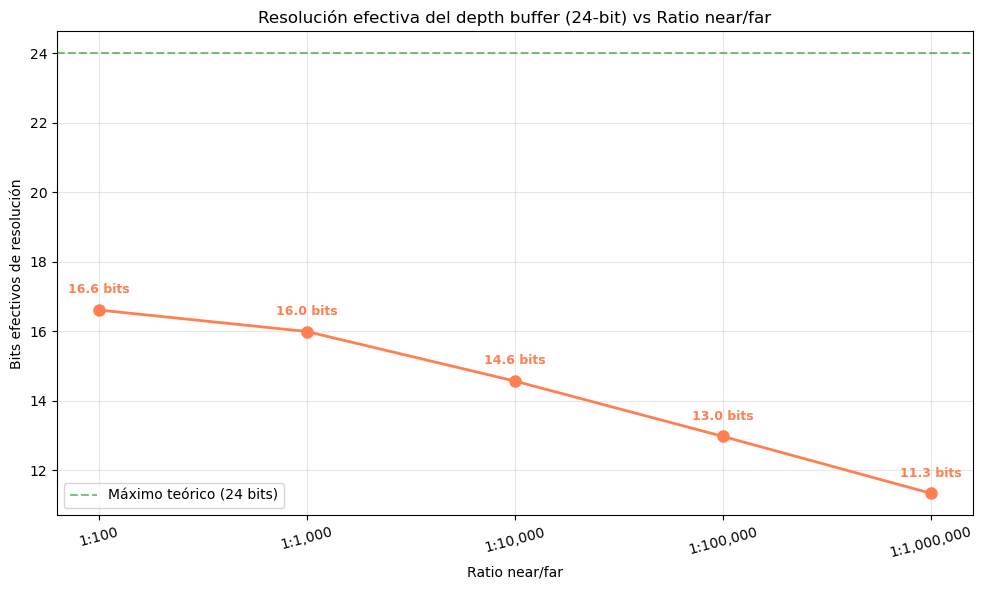

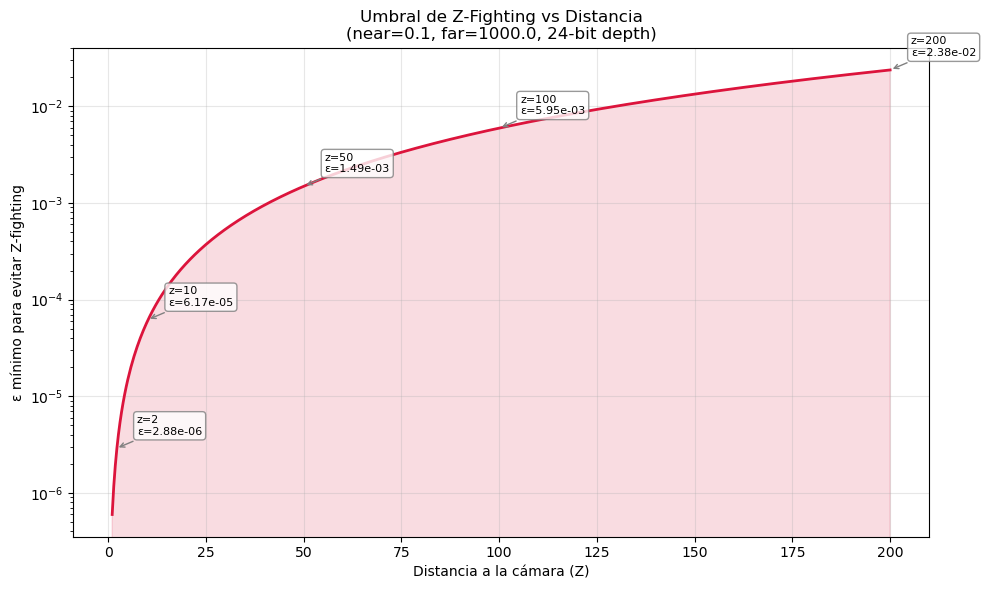

In [155]:
# ── 1. Depth buffer precision vs distance from camera ──

near_vals = [0.1, 0.01, 0.001]
far = 1000.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_i, near in enumerate(near_vals):
    distances = np.linspace(near, far, 10000)
    z_ndc = (far * (distances - near)) / (distances * (far - near))
    precision = np.abs(np.gradient(z_ndc, distances))

    axes[ax_i].semilogy(distances, precision, color="steelblue", linewidth=1.5)
    axes[ax_i].set_xlabel("Distancia a la cámara")
    axes[ax_i].set_ylabel("Precisión del depth buffer (dz_ndc/dz)")
    axes[ax_i].set_title(f"near={near}, far={far}\nratio 1:{int(far/near):,}")
    axes[ax_i].grid(True, alpha=0.3)
    axes[ax_i].axhline(y=1e-6, color="red", linestyle="--", alpha=0.5, label="Umbral float32")
    axes[ax_i].legend()

plt.suptitle("Precisión del depth buffer vs Distancia a la cámara", fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "precision_vs_distance.png"), dpi=150, bbox_inches="tight")
plt.show()


# ── 2. Near/far ratio vs effective depth resolution ──

ratios = [100, 1000, 10000, 100000, 1000000]
near_base = 1.0

effective_bits = []
for ratio in ratios:
    far_val = near_base * ratio
    z_samples = np.linspace(near_base, far_val, 100000)
    z_ndc = (far_val * (z_samples - near_base)) / (z_samples * (far_val - near_base))

    bits = 24
    quantized = np.round(z_ndc * (2**bits - 1)) / (2**bits - 1)
    unique_levels = len(np.unique(quantized))
    effective_bits.append(np.log2(unique_levels) if unique_levels > 0 else 0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot([f"1:{r:,}" for r in ratios], effective_bits, "o-", color="coral", linewidth=2, markersize=8)
ax.set_xlabel("Ratio near/far")
ax.set_ylabel("Bits efectivos de resolución")
ax.set_title("Resolución efectiva del depth buffer (24-bit) vs Ratio near/far")
ax.axhline(y=24, color="green", linestyle="--", alpha=0.5, label="Máximo teórico (24 bits)")
for i, (r, b) in enumerate(zip(ratios, effective_bits)):
    ax.annotate(f"{b:.1f} bits", (i, b), textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=9, color="coral", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "resolution_vs_near_far_ratio.png"), dpi=150, bbox_inches="tight")
plt.show()


# ── 3. Z-fighting threshold vs distance ──

test_depths_continuous = np.linspace(1.0, 200.0, 500)
near_test = 0.1
far_test = 1000.0

min_epsilons = []
for z1 in test_depths_continuous:
    z_ndc_1 = (far_test * (z1 - near_test)) / (z1 * (far_test - near_test))
    ndc_step = 1.0 / (2**24)
    z_ndc_2 = z_ndc_1 - ndc_step
    z2 = (far_test * near_test) / (far_test - z_ndc_2 * (far_test - near_test))
    min_epsilons.append(abs(z2 - z1))

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(test_depths_continuous, min_epsilons, color="crimson", linewidth=2)
ax.set_xlabel("Distancia a la cámara (Z)")
ax.set_ylabel("ε mínimo para evitar Z-fighting")
ax.set_title(f"Umbral de Z-Fighting vs Distancia\n(near={near_test}, far={far_test}, 24-bit depth)")
ax.grid(True, alpha=0.3)
ax.fill_between(test_depths_continuous, min_epsilons, alpha=0.15, color="crimson")

# Annotate a few key points
for z_mark in [2, 10, 50, 100, 200]:
    idx = np.argmin(np.abs(test_depths_continuous - z_mark))
    eps_val = min_epsilons[idx]
    ax.annotate(f"z={z_mark}\nε={eps_val:.2e}", (z_mark, eps_val),
                textcoords="offset points", xytext=(15, 10),
                fontsize=8, arrowprops=dict(arrowstyle="->", color="gray"),
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "zfighting_threshold_vs_distance.png"), dpi=150, bbox_inches="tight")
plt.show()